# Sequencial  Workflow 

In [91]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict

In [92]:
#define class 
class BMI(TypedDict):
    weight: float
    height: float
    bmi: float 
    category : str 

In [93]:
#function calculate BMI 
def bmi_calculator(state: BMI) -> BMI:

    weight = state['weight']
    height = state['height']

    bmi = weight / (height **2 )

    #upate state 

    state['bmi'] = round(bmi, 2)

    return state



In [94]:
def bmi_cat(state: BMI) -> BMI:
    bmi = state['bmi']

    if bmi < 18.5 :
        state["category"] = 'Underweight'
    elif 18.5 <= bmi < 25 :
        state["category"] = 'Normal weight'
    elif 25 <= bmi < 30 :
        state["category"] = 'Overweight'
    else :
        state["category"] = 'Obesity'
    return state

In [95]:
#define graph

graph = StateGraph(BMI)

#define nodes

graph.add_node("Calculate BMI",bmi_calculator)
graph.add_node("Category " , bmi_cat)

#define edges 

graph.add_edge(START,"Calculate BMI")
graph.add_edge("Calculate BMI","Category ")
graph.add_edge("Category ",END)

#define complile 
workflow = graph.compile()

In [96]:
# execute workflow

initial_State = {"weight": 70.0, "height": 1.75}

final_State  = workflow.invoke(initial_State)

print(final_State)

{'weight': 70.0, 'height': 1.75, 'bmi': 22.86, 'category': 'Normal weight'}


In [97]:
#visualize workflow
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())

ValueError: Failed to reach https://mermaid.ink API while trying to render your graph after 1 retries. To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

# LLM Workflow

In [ ]:
import os 
from dotenv import load_dotenv
from langchain_huggingface import HuggingFaceEndpoint , ChatHuggingFace


In [ ]:
#load environment 
load_dotenv()

True

In [ ]:
#check token 
token = os.getenv("HUGGINGFACEHUB_API_TOKEN")
if not token:
    print("Error: HUGGINGFACEHUB_API_TOKEN is not set in the .env file.")
else:
    print("Done")

Done


In [ ]:
#  Setup the Endpoint
repo_id = "meta-llama/Llama-3.1-8B-Instruct"

llm_H = HuggingFaceEndpoint(
    repo_id=repo_id,
    task="text-generation",
    max_new_tokens=512,
    temperature=0.7,
    huggingfacehub_api_token=token,
)

In [ ]:
#  Wrap it in ChatHuggingFace (This handles the "conversational" format for you)
model = ChatHuggingFace(llm=llm_H)

In [ ]:
#state 

class LLMstate(TypedDict):
    question : str 
    answer : str 

In [ ]:
def llm_ans(state : LLMstate) -> LLMstate:
    question = state['question']
    prompt = f"Answer the question : {question}"
    answer  = model.invoke(prompt).content
    state['answer'] = answer
    return state

In [ ]:
# graph 

graph = StateGraph(LLMstate)
# nodes 
graph.add_node("LLM_ans" , llm_ans)
# edges 
graph.add_edge(START,"LLM_ans")
graph.add_edge("LLM_ans",END)
# complile 
workflow = graph.compile()

In [ ]:
# execute workflow

initial_state = {"question": "What is the capital of France?"}
final_State = workflow.invoke(initial_state)
print(final_State['answer'])

The capital of France is Paris.


# Prompt Chaining Workflow

In [125]:
class BlogState(TypedDict):
    title : str 
    content : str 
    outline: str 
    evaluation  : str

In [126]:
def generate_outline(state : BlogState) -> BlogState:
    title = state['title']
    prompt = f"Generate an outline for a blog post with the title : {title}"
    outline = model.invoke(prompt).content
    state['outline'] = outline
    return state

In [127]:
def generate_blog(state : BlogState) -> BlogState:
    title = state['title']
    outline = state['outline']
    prompt = f"Generate a blog have title {title} post based on the following outline : {outline}"
    content = model.invoke(prompt).content
    state['content'] = content
    return state

In [131]:
def evaluate_blog(state: BlogState) -> BlogState:
    title = state['title']
    content = state['content']
    
    prompt = f"Evaluate the quality of the following blog post content: {content} having title {title}"
    evaluation = model.invoke(prompt).content  # generate evaluation
    state['evaluation'] = evaluation  # add to state
    
    return state

In [132]:
#graph 
graph = StateGraph(BlogState)
#nodes 
graph.add_node("Generate Outline", generate_outline)
graph.add_node("Generate Blog", generate_blog)
graph.add_node("Evaluate Blog", evaluate_blog)
#edges  
graph.add_edge(START , "Generate Outline")
graph.add_edge("Generate Outline" , "Generate Blog")
graph.add_edge("Generate Blog" , "Evaluate Blog")
graph.add_edge("Evaluate Blog" , END)
#compile 
workflow = graph.compile()

In [133]:
initial_state_gb = {"title": "The Benefits of AI in Healthcare"}
fs_gb = workflow.invoke(initial_state_gb)
print(fs_gb)

{'title': 'The Benefits of AI in Healthcare', 'content': "**The Benefits of AI in Healthcare**\n\nThe healthcare industry has come a long way in embracing technology to improve patient outcomes, streamline clinical workflows, and enhance the overall quality of care. Artificial Intelligence (AI) has emerged as a critical component of this transformation, promising to revolutionize the way healthcare is delivered. In this blog post, we will explore the benefits of AI in healthcare, highlighting its potential to improve patient outcomes, enhance clinical decision support, streamline clinical workflows, increase accessibility and personalization, and transform the industry as a whole.\n\n**I. Introduction**\n\nThe role of technology in healthcare has been increasing over the years, with electronic health records (EHRs), telemedicine, and medical devices becoming more prevalent. However, AI has the potential to take healthcare to the next level by leveraging machine learning algorithms, nat

In [134]:
print(fs_gb.keys())

dict_keys(['title', 'content', 'outline', 'evaluation'])


In [135]:
print(fs_gb['outline'])

Here's an outline for a blog post on "The Benefits of AI in Healthcare":

**I. Introduction**

* Brief overview of the role of technology in healthcare
* Explanation of the increasing importance of Artificial Intelligence (AI) in healthcare
* Thesis statement: AI has the potential to revolutionize healthcare by improving patient outcomes, streamlining clinical workflows, and enhancing the overall quality of care.

**II. Improved Patient Outcomes**

* Discussion of how AI can help diagnose diseases more accurately and quickly
* Explanation of how AI-powered predictive analytics can help identify high-risk patients and prevent hospital readmissions
* Examples of AI-based systems that have improved patient outcomes in real-world settings

**III. Enhanced Clinical Decision Support**

* Explanation of how AI can provide clinicians with real-time, data-driven insights to inform treatment decisions
* Discussion of how AI-powered chatbots can help patients and clinicians communicate more effec

In [136]:
print(fs_gb['evaluation'])

**Content Quality Evaluation: 8.5/10**

The blog post "The Benefits of AI in Healthcare" provides a comprehensive overview of the role of Artificial Intelligence (AI) in the healthcare industry. Here's a breakdown of the content quality:

**Strengths:**

1. **Clear structure:** The post has a clear and logical structure, with four main sections: Introduction, Improved Patient Outcomes, Enhanced Clinical Decision Support, and Accessibility and Personalization.
2. **Relevant information:** The post provides relevant and up-to-date information on the benefits of AI in healthcare, including real-world examples and statistics.
3. **Engaging writing style:** The writing style is clear and concise, making it easy to understand for a general audience.
4. **Use of visual aids:** The post could benefit from the inclusion of visuals, such as infographics or images, to break up the text and make it more engaging.

**Weaknesses:**

1. **Lack of depth:** While the post provides a good overview of th

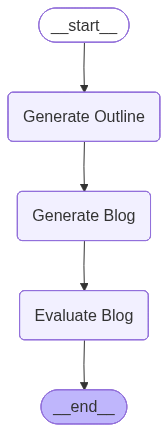

In [ ]:
#visualize workflow
from IPython.display import Image 
Image(workflow.get_graph().draw_mermaid_png())